<a href="https://colab.research.google.com/github/Giobz/Data-Science/blob/master/DiabetesTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset Retrieve
Dataset set retrieved from https://archive.ics.uci.edu . It is a vast medical dataset open source. For the sake of this analysis the dataset chosen relates to Diabetes data source gathered across 130 US hospitals between years 1999-2008.



In [199]:
pip install ucimlrepo

## Initial Dataset Exploration

### Explore the variables:
In this step I am exploring the whole dataset variables, rows and values. This first stage aioms to identify the metadata, column names, variable type, features and targets, etc..

**Why**:
Performing this step can clarify the dataset to understand how it can be analysed initialy and what results we can get from the analysis.



In [200]:
from ucimlrepo import fetch_ucirepo
import pprint

# fetch dataset
diabetes_df = fetch_ucirepo(id=296)

#METADATA
pprint.pp(diabetes_df.metadata)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296,
 'name': 'Diabetes 130-US Hospitals for Years 1999-2008',
 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008',
 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv',
 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at '
             '130 US hospitals and integrated delivery networks. Each row '
             'concerns hospital records of patients diagnosed with diabetes, '
             'who underwent laboratory, medications, and stayed up to 14 days. '
             'The goal is to determine the early readmission of the patient '
             'within 30 days of discharge.\n'
             'The problem is important for the following reasons. Despite '
             'high-quality evidence showing improved clinical outcomes for '
             'diabetic patients who receive various preventive and therapeutic '
             'interventions, many patients do not receive them. This can

In [201]:
# import pandas as pd

# diabetes_df = pd.DataFrame()
# diabetes_df.to_csv('diabetes130Us.csv')

In [202]:
diabetes_df.metadata.intro_paper.title

'Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Record'

In [203]:
diabetes_df.metadata.additional_info.summary

'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.\n(1)\tIt is an inpatient encounter (a hospital admission).\n(2)\tIt is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.\n(3)\tThe length of stay was at least 1 day and at most 14 days.\n(4)\tLaboratory tests were performed during the encounter.\n(5)\tMedications were administered during the encounter.\n\nThe data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitaliza

In [204]:
diabetes_df.variables

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,None,Unique identifier of an encounter,None,no
1,patient_nbr,ID,,None,Unique identifier of a patient,None,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",None,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20...",None,no
5,weight,Feature,Categorical,None,Weight in pounds.,None,yes
6,admission_type_id,Feature,Categorical,None,Integer identifier corresponding to 9 distinct...,None,no
7,discharge_disposition_id,Feature,Categorical,None,Integer identifier corresponding to 29 distinc...,None,no
8,admission_source_id,Feature,Categorical,None,Integer identifier corresponding to 21 distinc...,None,no
9,time_in_hospital,Feature,Integer,None,Integer number of days between admission and d...,None,no


In [205]:
diabetes_df.data.features

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,...,No,No,Down,No,No,No,No,No,Ch,Yes
101762,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
101763,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,...,No,No,Down,No,No,No,No,No,Ch,Yes
101764,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,...,No,No,Up,No,No,No,No,No,Ch,Yes


In [206]:
diabetes_df.data.targets

,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO
...,...
101761,>30
101762,NO
101763,NO
101764,NO


In [207]:
# data (as pandas dataframes)
X = diabetes_df.data.features
y = diabetes_df.data.targets

# Display information about the features DataFrame
X.info()

# Display information about the target DataFrame
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [208]:
diabetes_df.data.ids   # this dataset has IDs for "encounter_id" and "patient_nbr"


,encounter_id,patient_nbr
0,2278392,8222157
1,149190,55629189
2,64410,86047875
3,500364,82442376
4,16680,42519267
...,...,...
101761,443847548,100162476
101762,443847782,74694222
101763,443854148,41088789
101764,443857166,31693671


In [209]:
diabetes_df.data.features.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [210]:
diabetes_df.data.targets.describe()

,readmitted
count,101766
unique,3
top,NO
freq,54864


In [211]:
diabetes_df.data.features.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [212]:
diabetes_df.data.targets.head()

,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO


In [213]:
diabetes_df.data.features.tail()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
101761,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,...,No,No,Down,No,No,No,No,No,Ch,Yes
101762,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
101763,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,...,No,No,Down,No,No,No,No,No,Ch,Yes
101764,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,...,No,No,Up,No,No,No,No,No,Ch,Yes
101765,Caucasian,Male,[70-80),NaN,1,1,7,6,NaN,NaN,...,No,No,No,No,No,No,No,No,No,No


In [214]:
diabetes_df.data.targets.tail()

,readmitted
101761,>30
101762,NO
101763,NO
101764,NO
101765,NO


In [215]:
diabetes_df.data.features.shape

(101766, 47)

In [216]:
diabetes_df.data.targets.shape

(101766, 1)

In [217]:
diabetes_df.data.features.dtypes

,0
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
payer_code,object
medical_specialty,object


In [218]:
diabetes_df.data.targets.dtypes

,0
readmitted,object


In [219]:
diabetes_df.data.features.isnull().sum()

,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,40256
medical_specialty,49949


In [220]:
diabetes_df.data.targets.isnull().sum()

,0
readmitted,0


In [221]:
diabetes_df.data.features.duplicated().sum()

np.int64(0)

In [222]:
diabetes_df.data.targets.duplicated().sum()

np.int64(101763)

## Identify non-numeric columns

Determine which columns in the features DataFrame are object or categorical type.


**Reasoning**:
Iterate through the columns of the features DataFrame and print the names of columns with 'int64' dtype.



In [223]:
# Iterate through the columns of the features DataFrame
for col in X.columns:
  # Check the data type of the column
  if X[col].dtype == 'int64':
    # Print the name of the column if its data type is 'object'
    print(col)

admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
number_diagnoses


## Handle non-numeric columns

### Columns selection:
Given that the correlation matrix requires numerical variables, the categorical variables cannot be envolvced in this proccess.

**Why**:
This selection is important because only the numerical columns can be correlated to each other.


In [224]:
X_numeric_cols = X
numeric_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

X_numeric_cols = X_numeric_cols[numeric_cols]
X_numeric_cols.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,6,25,1,1,41,0,1,0,0,0,1
1,1,1,7,3,59,0,18,0,0,0,9
2,1,1,7,2,11,5,13,2,0,1,6
3,1,1,7,2,44,1,16,0,0,0,7
4,1,1,7,1,51,0,8,0,0,0,5


## Calculate correlation matrix

### Subtask:
After handling non-numeric columns, calculate the correlation matrix on the modified DataFrame.

**Why**:
Calculate the correlation matrix for the numeric features.

In [225]:
correlation_matrix = X_numeric_cols.corr()

## Visualize the correlation matrix

### Heatmap:
Visualize the correlation matrix using the heatmap

**Why**:
The heatmap represent in colors the variables with more correlation. As much the number is close to 1 stronger is the correlation


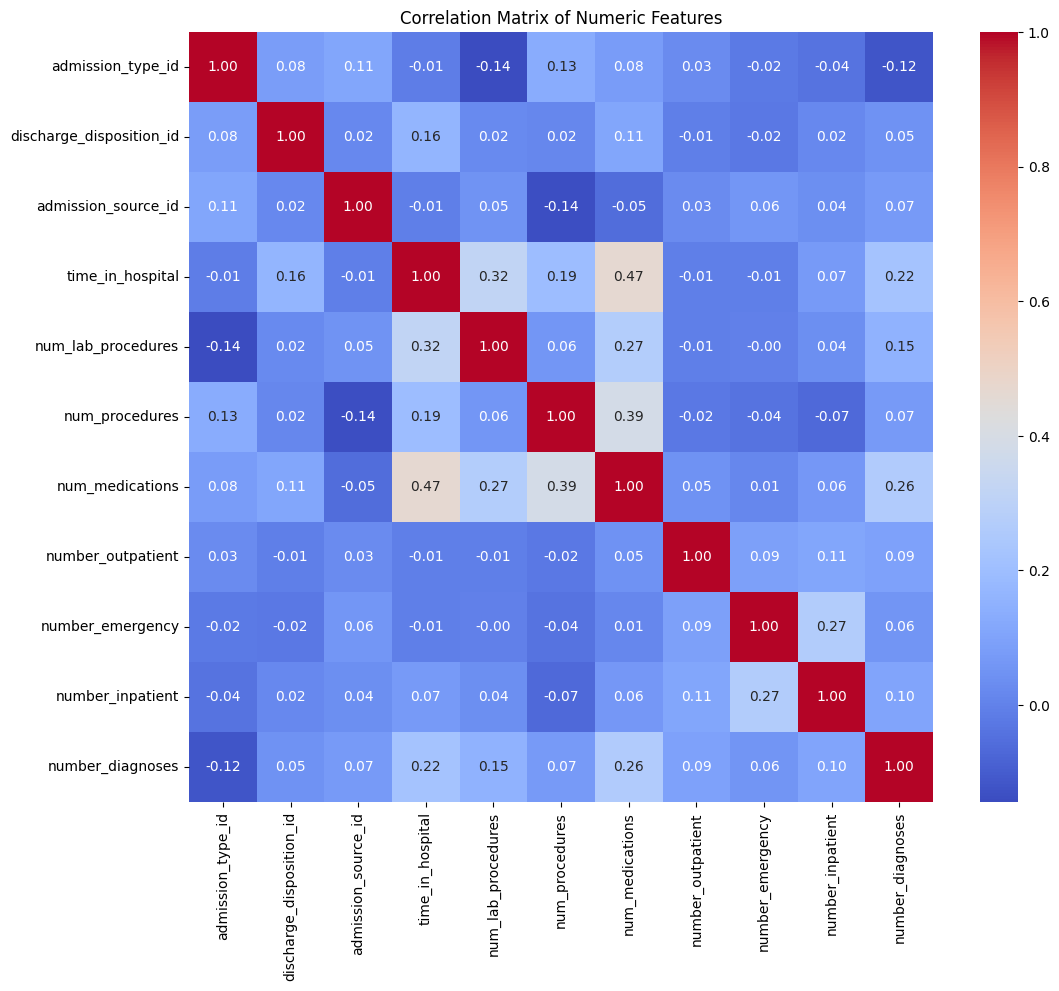

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Summary:

### Data Analysis Key Findings

*   Initially, the code attempted to calculate a correlation matrix on a DataFrame containing non-numeric columns, which would lead to an error.
*   The non-numeric columns were keep in the dataset stored in "X" and only the numerical ones were used for the correlation matrix.
*   A heatmap visualizing the correlation matrix helps to identinfy the correlated features.

### Insights or Next Steps

*   The initial error was due to attempting to calculate correlations on non-numeric data. Removing these columns resolved the issue.
*   The visualized correlation matrix allows for identifying relationships between the remaining numeric features, which can inform subsequent steps in the analysis or modeling process.


## Explore Target Variable Distribution

Examine the distribution of the target variable 'readmitted'.

**Why**:
Visualize the distribution of the 'readmitted' column to understand the class balance.

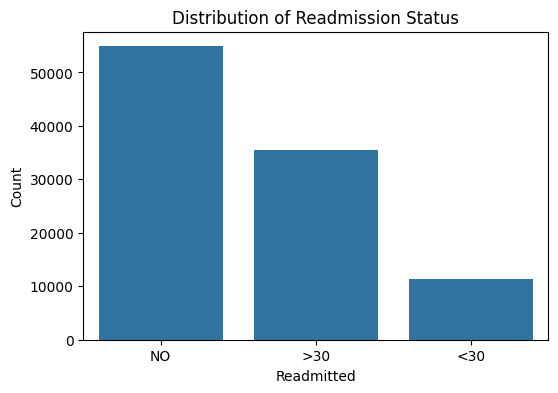

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted', data=y)
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

##

## Identify columns with missing values

Identify columns with missing values by reviewing the output of `isnull().sum()`.


## Implement of imputation Strategy by mode

Implement imputation strategy for handling missing values in the features DataFrame `X`.

**Why**:
Implement the missing value handling strategies by dropping specified columns and imputing the mode for the remaining categorical columns.



In [228]:
X.isnull().sum()

,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,40256
medical_specialty,49949


In [229]:
# Identify the columns that still exist in X and have missing values
cols_with_missing = X.columns[X.isnull().any()].tolist()

# Identify categorical and numerical columns among those with missing values
categorical_cols_to_impute = X[cols_with_missing].select_dtypes(include='object').columns
numerical_cols_to_impute = X[cols_with_missing].select_dtypes(include='int64').columns


# Impute missing values in the categorical columns with the mode
for col in categorical_cols_to_impute:
    X[col] = X[col].fillna(X[col].mode()[0])

# Impute missing values in the numerical columns with the mode (or consider mean/median)
for col in numerical_cols_to_impute:
     X[col] = X[col].fillna(X[col].mode()[0])


# Verify that there are no more missing values in the modified DataFrame
print(X.isnull().sum().sum())

/tmp/ipython-input-4215112642.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


0


## Verify missing values are handled

### Subtask:
Verify that all missing values in the features DataFrame `X` have been successfully handled.


**Reasoning**:
Calculate and print the sum of missing values for each column in the DataFrame X to confirm that all missing values have been handled.



In [230]:
print(X.isnull().sum())

race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

In [231]:
X.diag_1.isnull().sum()
X.diag_1

,diag_1
0,250.83
1,276
2,648
3,8
4,197
...,...
101761,250.13
101762,560
101763,38
101764,996


In [232]:
X.diag_2.isnull().sum()

np.int64(0)

In [233]:
X.diag_3.isnull().sum()

np.int64(0)

In [234]:
X.max_glu_serum.isnull().sum()

np.int64(0)

In [235]:
X.A1Cresult.isnull().sum()

np.int64(0)

## Summary:

### Data Analysis Key Findings

*   Initially, several columns were identified with missing values, ranging from 1 (`Electrical`) to 1453 (`PoolQC`).
*   Columns with a large number of missing values (`Alley`, `PoolQC`, `Fence`, `MiscFeature`) were targeted for dropping.
*   Numerical columns with missing values (`LotFrontage`, `GarageYrBlt`, `MasVnrArea`) were considered for imputation using median or mean.
*   Categorical columns with missing values were planned for imputation using the mode.
*   After implementing the strategies (dropping specific columns and imputing the mode for remaining categorical columns), the total number of missing values in the DataFrame `X` was reduced to 0.

### Insights or Next Steps

*   The choice of imputation strategy (mean, median, mode) should ideally be guided by the distribution of the data and domain knowledge.
*   For features where missing values might indicate absence (e.g., basement or garage features), a specific imputation value representing "none" could be more informative than the mode.
